We consider a number field $K$ with class number $h$. In order to prove non-principality of one of the generators of $\mathcal{Cl_K}$, of order $m$, say, we will need to know the unit group up to p-powers. This can be done by computing candidates for the basis of this group (mod torsion), and testing if it's p-saturated. The latter is done by finding a collection of prime ideals $\mathfrak{q}_1, \ldots, \mathfrak{q}_n$ where $p \mid N(\mathfrak{q}_i) - 1$, and computing the rank of a matrix where the entry $(i,j)$ corresponds to $\operatorname{Log}_{\mathfrak{q}_i}(\zeta_j)$, where $\operatorname{Log}_{\mathfrak{q}_i} : \mathcal{O}_K \to \mathbb{F}_p$ is a discrete logarithm function on $\mathcal{O}_K/\mathfrak{q}_i$ composed with reduction modulo $p$. 

It can be shown that $\beta \in \mathcal{O}_K$ is a $p$-power if and only if $\operatorname{Log}_{\mathfrak{q}}(\beta) = 0$ for every prime ideal $\mathfrak{q}$ not containing $\beta$ (otherwise, the map is not defined). 

A consequence of Chabotarev is that, given $\beta \in \mathcal{O}_K$ not a $p$-power and a prime ideal $\mathfrak{q}$ such that $p \mid N(\mathfrak{q}) - 1$, then the probability that $\operatorname{Log}_{\mathfrak{q}}(\beta) = 0$ is $1/p$. That is, the quotient $\frac{\{\mathfrak{q} | N(\mathfrak{q}) \leq m , p \mid (N(\mathfrak{q}) -1) , \operatorname{Log}_{\mathfrak{q}}(\beta) = 0 \}}{\{ \mathfrak{q} | N(\mathfrak{q}) \leq m, p \mid N(\mathfrak{q}) -1 \}} \to 1 / p$. Because this is a positive density and primes of degree greater than 1 have density zero, the same thing holds if we restrict ourselves to primes of inertia degree one. Is this behaviour seen in practice for 'low' bounds on the norm? 

In [303]:
#Let I be a prime ideal. Test if r is a generator for (O/I)*  

def IsGenMod (O, I, r):
    Rm = QuotientRing(O , I, 'y')
    n = I.norm() - 1
    F = factor(I.norm() - 1)
    if Rm(r) != 0 : 
        for p in F: 
            if Rm(r) ^ int(n / p[0]) == 1 :
                return false 
        return true 
    else: 
        return false    

In [826]:
# Find primitive root for (O/I)*. We use a random element of O instead of ZZ(1,sqrt(p)) because we allow I to have degree
# bigger than one
def PrimitiveRootMod (O, I) :
    R = QuotientRing(O , I, 'y')
    n = I.norm() - 1
    set_seed = 2
    for i in range(50):
        r = O.random_element()
        #r = ZZ.random_element(1, ceil(sqrt(n + 1)))
        #r = range(1,ceil(sqrt(n + 1))).random_element()
        if IsGenMod(O, I, r) : 
            return r 


In [816]:
# We are brute forcing the computation of this discrete logarithm. If we have a map to Z/nZ, we can use more efficient 
# methods. Find log(x) with basis z. 

def DiscreteLog (O, I, x, z): 
    R = QuotientRing(O , I, 'y')
    for i in range(I.norm()):
        if R(x) == R(z) ^ i :
            return i 

In [817]:
# Test if x is a p-power in O/I 

def IsPPower (O, I, x, p): 
    R = QuotientRing(O , I, 'y')
    z = PrimitiveRootMod (O, I)
    if R(x) != 0:
        for i in range(((I.norm() - 1) / p) + 1):
            if R(x) == R(z) ^ (p * i) :
                return true 
        return false 
    else :
        return true

In [300]:
# Lists of number fields with class group isomorphic to C_2 \times C_2 
f20 = x^2 + 33
f21 = x^2 - 130263
f22 = x^2 - 13870
f23 = x^2 - x - 167446
f31 = x^3 - 69*x - 4492
f41 = x^4 + 381938
f51 = x^5 - 75*x^2 - 225*x + 1215
f61 = x^6 - 2*x^5 + 40*x^4 + 1034*x^3 - 3600*x^2 + 26738*x + 145377

In [582]:
# Count the number of prime ideals up to a certain bound that satisfy property1 and property2 

def property1 (I,p) : 
    if (I.norm() - 1) % p == 0 : 
        return true 
    else : 
        return false 

# L1 is the list of prime ideals up to norm N satisfying property 1, and L2 is the sublist of those primes for which x is a p-power. 
# We tag each entry with the norm of the ideal for later sorting. 
def IdealsNormLeqBound (K, N, x, p):
    O = K.ring_of_integers()
    cont1 = 0 
    L1 = []
    cont2 = 0 
    L2 = []
    cont3 = 0 
    for q in primes(N + 1):
        F = factor(O.ideal(q))
        for P in F: 
            if P[0].norm() <= N and (not x in P[0]):
                if property1 (P[0], p):
                    cont1 = cont1 + 1 
                    L1 = L1 + [(P[0].norm(), P[0])]
                    if IsPPower(O, P[0], x, p): 
                        cont2 = cont2 + 1 
                        L2 = L2 + [(P[0].norm(), P[0])]
            cont3 = cont3 + 1
    return L1, cont1, L2, cont2, cont3 




In [823]:
## Compute data up to bound N, with respect to the prime p and the element x 
R.<x> = PolynomialRing(QQ)
K.<a> = NumberField (f21)
x = 6 
p = 2
M = 200

L1, cont1, L2, cont2, cont3 = IdealsNormLeqBound(K, M, x, p)

In [824]:
# For each norm N, compute the ratio of prime ideals where x is a p-power with respect to ideals satisfying property1. 
# Ld contains the same information restricted to prime ideals of inertia degree 1. 
def ComputeRatios (L1, L2) : 
    L = []
    Ld = []
    for N in range(2, M): 
        contt = 0 
        conta = 0 
        conttd = 0 
        contad = 0 
        for x in L1 : 
            if x[0] <= N:
                contt = contt + 1
                if is_prime(ZZ(x[0])):
                    conttd = conttd + 1
        for x in L2 : 
            if x[0] <= N : 
                conta = conta + 1
                if ZZ(x[0]).is_prime():
                    contad = contad + 1
        if contt != 0 :
            L = L + [(N , conta / contt)]
        if conttd != 0 :
            Ld = Ld + [(N , contad / conttd)]
    return L, Ld

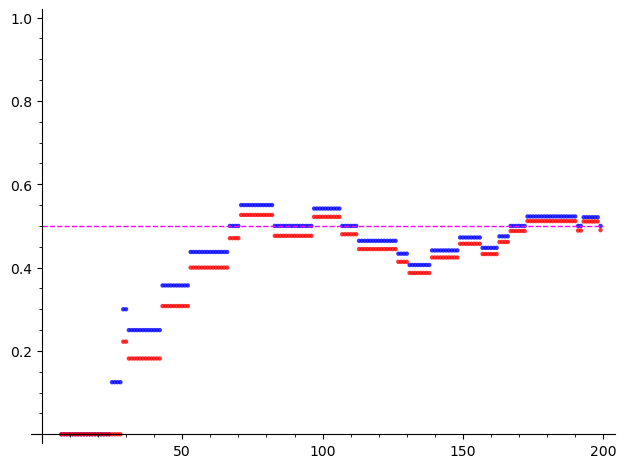

In [825]:
# Plot the ratios. Blue is considering any inertia degree, red is restricting to inertia degree 1. 
# The ratio is (#primes where x is a p-power / #primes)
# red is primes of inertia degree 1
L, Ld = ComputeRatios (L1, L2) 
plot1 = list_plot(L, ymin = 0 , ymax = 1, color = 'blue', alpha = 0.8)
plot2 = list_plot(Ld, ymin = 0, ymax = 1, color = 'red', alpha = 0.8)
plot3 = plot(1/p, 0, M, color='#ff00ff', linestyle='--')

(plot1 + plot2 + plot3)

In [518]:
# Given a list of entries of the form (m, I), order them by first entry and extract the first n entries. 

def PrimeIdealsOrdered (L, n):
    if n > len(L):
        print('List is not big enough')
    else : 
        Ls = sorted (L, key = lambda x: x[0])
        return Ls[: n]

In [685]:
#Given a list of primes ideals tagged with their norm LP, a list of units L, an element s, and a prime p, this generates an n x (len(L) + 1) matrix, where each row is obtain by applying 
# a different q-logarithm. 

def MatrixQLogarithm (K, O, LP, L, s, p, n):
    Q = PrimeIdealsOrdered(LP,n)
    L = L + [s]
    A = [[0 for j in range(len(L))] for i in range(n)]
    for i in range(n) :
        z = PrimitiveRootMod (O, Q[i][1])
        for j in range(len(L)):
            A[i][j] = DiscreteLog(O, Q[i][1], L[j], z) % p  
    return Matrix(A) , Q[: n]

In [706]:
# Compute matrix to prove nonprincipality of ideal such that I ^ p = (x) using prime ideals of any degree and only of 
# degree 1. T is the bound given for the norms of the ideals. 
# Q is the list of ideals needed to arrive at a full-rank matrix, Q2 is the analogue with only primes of degree 1
def MatrixPrimes (K, O, p, x, T):
    L = []
    U = K.unit_group().gens()
    
    for i in range(len(U)):
        if i == 0 :
            if order(K.unit_group().gens()[0]) % p == 0: # If p divides torsion order, we include it in the columns 
                L = L + [K.unit_group().gens()[0]]
        else : 
            L = L + [K.unit_group().gens()[i]]
    
    L1, cont1, L2, cont2, cont3 = IdealsNormLeqBound(K, T, x, p)
    
    n = len(L) + 1
    
    #Taking into account all prime ideals with p | N(I) - 1. 
    A = Matrix([])
    while A.change_ring(GF(p)).rank() != len(L) + 1: 
        A, Q = MatrixQLogarithm(K, O, L1, L, x, p, n)
        n = n + 1
 #       print(A)
        
    L1d = [x for x in L1 if ZZ(x[0]).is_prime()]
    
    m = len(L) + 1
    
    #Taking into account prime ideals of degree 1 
    B = Matrix([])
    while B.change_ring(GF(p)).rank() != len(L) + 1: 
        B, Q2 = MatrixQLogarithm(K, O, L1d, L, x, p, m)
        m = m + 1
#        print(B)
        
    return A ,Q, B, Q2



In [707]:
#Fields with class group either C2 x C2 or C2. 
R.<x> = PolynomialRing(QQ)

NF2 = [x^2 + 33, x^2 - 130263, x^2 - 13870, x^2 - x - 167446, x^3 - 69*x - 4492, x^4 + 381938,
x^5 - 75*x^2 - 225*x + 1215, x^6 - 2*x^5 + 40*x^4 + 1034*x^3 - 3600*x^2 + 26738*x + 145377, 
x^7 - 2*x^6 + 2*x^5 - 3*x^4 + 5*x^3 - 7*x^2 + 4*x - 1, x^8 - 4*x^7 + 8*x^6 - 10*x^5 + 11*x^4 - 10*x^3 + 2*x^2 + 2*x + 1, 
x^8 - 3*x^7 + 6*x^6 - 6*x^5 + 8*x^4 - 6*x^3 + 6*x^2 - 3*x + 1,
x^9 - x^8 + 5*x^7 - 6*x^6 + 5*x^5 - 14*x^4 - 3*x^3 - 10*x^2 - 3*x - 1, x^9 - x^8 - 2*x^7 + 4*x^6 + 3*x^5 - 7*x^4 + 7*x^3 - 5*x^2 - x + 9, 
x^10 - 3*x^9 + 3*x^8 - 6*x^7 + 11*x^6 - 5*x^5 + 7*x^4 - 11*x^3 + 3*x + 1, x^10 - 2*x^9 + 5*x^6 - 4*x^5 + 6*x^4 - 10*x^3 + 5*x^2 - x + 1, 
x^11 + 4*x - 1, x^11 - x^10 - 5*x^9 - 35*x^8 + 80*x^7 + 112*x^6 + 288*x^5 - 1440*x^4 + 1728*x - 1728,       
x^12 - x^11 + 5*x^10 - 10*x^9 + 9*x^8 - 9*x^7 + 14*x^6 + 9*x^5 + 9*x^4 + 10*x^3 + 5*x^2 + x + 1 ]

#LQ1 = []
#LQ2 = []

for i in range(len(NF2)):
    K.<a> = NumberField(R(NF2[i]))
    O = K.ring_of_integers()
    I = O.ideal(K.class_group().gens()[0].gens())
    F = factor(order(K.class_group().gens()[0]))
    p = F[0][0]
    x = (O.ideal(K.class_group().gens()[0].gens()) ^ p).gens_reduced()[0]
    if R(NF2[i]).degree() <= 7 :
        A, Q, B , Q2 = MatrixPrimes(K, O, p, x, 200)
    else : 
        A, Q, B , Q2 = MatrixPrimes(K, O, p, x, 210)
    print(Q[-1][0],'vs.' ,Q2[-1][0])

17 vs. 17
11 vs. 11
13 vs. 13
7 vs. 7
7 vs. 7
19 vs. 19
31 vs. 31
17 vs. 17
11 vs. 11
49 vs. 101
41 vs. 61
29 vs. 31
31 vs. 43
29 vs. 31
41 vs. 41
71 vs. 71
13 vs. 13
49 vs. 199


In [714]:
## Fields with class number 3 
R.<x> = PolynomialRing(QQ)

NF2 = [x^2 - 475351, x^2 - x - 340402, x^2 - x - 412342, x^2 - x - 245292, x^3 + 75*x - 120, x^4 - 2*x^3 + 73*x^2 + 98*x + 4753, 
x^5 - x^4 + x^3 - 6*x^2 + 8*x - 6, x^6 - 34*x^4 - 36*x^3 + 442*x^2 + 1341*x + 1119, x^7 - 882*x^4 + 1714608, x^8 + 54*x^4 + 733, 
x^8 - 3*x^7 + 2*x^6 + 51*x^5 + 242*x^4 - 897*x^3 + 2225*x^2 + 11190*x + 24196, x^9 - 3*x^8 - 15*x^7 + 27*x^6 + 126*x^5 - 198*x^4 - 1536*x^3 - 2736*x^2 - 1944*x - 204, 
x^9 - 3*x^8 - 45*x^7 + 182*x^6 + 468*x^5 - 2919*x^4 + 1679*x^3 + 7191*x^2 - 5034*x - 6499, x^10 - 4*x^9 - 9*x^8 + 50*x^7 - 20*x^6 - 166*x^5 + 183*x^4 - 6*x^3 + 193*x^2 - 370*x - 236, 
x^10 - 5*x^9 + 12*x^8 - 17*x^7 + 19*x^6 - 19*x^5 + 19*x^4 - 17*x^3 + 12*x^2 - 5*x + 1, 
x^12 - 3*x^11 + 7*x^10 - 8*x^9 + 3*x^8 + 21*x^7 - 20*x^6 + 21*x^5 + 19*x^4 - 22*x^3 + 21*x^2 - 5*x + 1 ]

#LQ1 = []
#LQ2 = []

for i in range(len(NF2)):
    K.<a> = NumberField(R(NF2[i]))
    O = K.ring_of_integers()
    I = O.ideal(K.class_group().gens()[0].gens())
    F = factor(order(K.class_group().gens()[0]))
    p = F[0][0]
    x = (O.ideal(K.class_group().gens()[0].gens()) ^ p).gens_reduced()[0]
    if R(NF2[i]).degree() <= 7 :
        A, Q, B , Q2 = MatrixPrimes(K, O, p, x, 100)
    else : 
        A, Q, B , Q2 = MatrixPrimes(K, O, p, x, 210)
    print(Q[-1][0],'vs.' ,Q2[-1][0])

61 vs. 61
37 vs. 37
19 vs. 19
37 vs. 37
13 vs. 13
19 vs. 67
97 vs. 97
19 vs. 19
43 vs. 61
61 vs. 61
4 vs. 37
19 vs. 19
67 vs. 67
31 vs. 37
79 vs. 79
25 vs. 151


In [810]:
R.<x> = PolynomialRing(QQ)

NF2 = [x^6 + x^5 + x^4 + x^3 + x^2 + x + 1, x^2 + 33, x^2 - 130263, x^2 - 13870, x^2 - x - 167446, x^4 + 381938, x^6 - 2*x^5 + 40*x^4 + 1034*x^3 - 3600*x^2 + 26738*x + 145377, 
x^8 - 4*x^7 + 8*x^6 - 10*x^5 + 11*x^4 - 10*x^3 + 2*x^2 + 2*x + 1, 
x^8 - 3*x^7 + 6*x^6 - 6*x^5 + 8*x^4 - 6*x^3 + 6*x^2 - 3*x + 1,
x^10 - 3*x^9 + 3*x^8 - 6*x^7 + 11*x^6 - 5*x^5 + 7*x^4 - 11*x^3 + 3*x + 1, x^10 - 2*x^9 + 5*x^6 - 4*x^5 + 6*x^4 - 10*x^3 + 5*x^2 - x + 1,       
x^12 - x^11 + 5*x^10 - 10*x^9 + 9*x^8 - 9*x^7 + 14*x^6 + 9*x^5 + 9*x^4 + 10*x^3 + 5*x^2 + x + 1 ]

NF3 = [x^2 - 475351, x^2 - x - 340402, x^2 - x - 412342, x^2 - x - 245292, x^4 - 2*x^3 + 73*x^2 + 98*x + 4753, 
 x^6 - 34*x^4 - 36*x^3 + 442*x^2 + 1341*x + 1119,
x^8 - 3*x^7 + 2*x^6 + 51*x^5 + 242*x^4 - 897*x^3 + 2225*x^2 + 11190*x + 24196, 
x^10 - 4*x^9 - 9*x^8 + 50*x^7 - 20*x^6 - 166*x^5 + 183*x^4 - 6*x^3 + 193*x^2 - 370*x - 236, 
x^10 - 5*x^9 + 12*x^8 - 17*x^7 + 19*x^6 - 19*x^5 + 19*x^4 - 17*x^3 + 12*x^2 - 5*x + 1, 
x^12 - 3*x^11 + 7*x^10 - 8*x^9 + 3*x^8 + 21*x^7 - 20*x^6 + 21*x^5 + 19*x^4 - 22*x^3 + 21*x^2 - 5*x + 1, x^ 10 + x^ 9 + x^8 + x ^ 7 + x^6 + x^5 + x^4 + x^3 + x^2 + x + 1]

NF = NF2 + NF3 
for f in NF: 
    K.<a> = NumberField(f)
    O = K.ring_of_integers()
    To = order(K.unit_group().gens()[0])
    Lp = [p for p in primes(K.degree() + 2) if ZZ(K.degree()) % (p - 1) == 0]
    L1, cont1, L2, cont2, cont3  = IdealsNormLeqBound (K, 100, 1, 2)
    Ld1 = sorted(set ([x[0] - 1 for x in L1 if ZZ(x[0]).is_prime() and ZZ(x[0]) not in Lp]))
    Ld2 = sorted(set ([x[0] - 1 for x in L1 if factor(ZZ(x[0]))[0][0] not in Lp]))
    
    for n in range(len(Ld1)):
        if gcd(Ld1[:n]) == To:
            print('torsion order is:',To, '. Look at prime ideals of degree 1 of norm', [x + 1 for x in Ld1[:n]])
            break
    
    for n in range(len(Ld2)):
        if gcd(Ld2[:n]) == To:
            print('  You can also look at prime ideals of norm', [x + 1 for x in Ld2[:n]])
            break

torsion order is: 14 . Look at prime ideals of degree 1 of norm [29, 43]
  You can also look at prime ideals of norm [29, 43]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [7, 11]
  You can also look at prime ideals of norm [7, 11]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [7, 11]
  You can also look at prime ideals of norm [7, 11]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [5, 13, 17, 19]
  You can also look at prime ideals of norm [5, 13, 17, 19]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [5, 7]
  You can also look at prime ideals of norm [5, 7]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [11, 17]
  You can also look at prime ideals of norm [11, 17]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [5, 11]
  You can also look at prime ideals of norm [5, 11]
torsion order is: 2 . Look at prime ideals of degree 1 of norm [23, 41]
  You can also look at prime ideals of norm [23,

In [786]:
K.<a> = NumberField(x^6 + x^5 + x^4 + x^3 + x^2 + x + 1)
To = order(K.unit_group().gens()[0])
Lp = [p for p in primes(K.degree() + 2) if ZZ(K.degree()) % (p - 1) == 0]
print(Lp)

[2, 3, 7]
